In [85]:
# Standard library
import os
from pathlib import Path
import math
from collections import defaultdict
import re
import random


# Third-party
import opendssdirect as dss
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [86]:
# --- DEFINIÇÃO DE CAMINHOS ROBUSTA ---
# 1. Identifica a pasta onde o notebook está rodando e sobe um nível ("..") para a raiz do projeto
# .resolve() elimina ambiguidades como ".." e retorna o caminho absoluto completo
PROJECT_ROOT = Path("..").resolve() 

# 2. Define o caminho para a pasta de dados (CSV)
BASE_DIR = PROJECT_ROOT / "data"

# 3. Define o caminho para o arquivo .dss
# Estrutura: raiz -> data -> 13Bus -> IEEE13Nodeckt.dss
# DSS_FILE = BASE_DIR / "13Bus" / "IEEE13Nodeckt.dss"

DSS_FILE = BASE_DIR / "123Bus" / "IEEE123Master.dss"

In [87]:
dss.Command("Clear")
# É crucial converter para string e usar resolve() para o OpenDSS entender o caminho
dss.Command(f"redirect '{str(DSS_FILE.resolve())}'")
dss.Command('Solve')

In [88]:
len(dss.Loads.AllNames())


91

In [89]:
load_names = dss.Loads.AllNames()

Map_Load_Qtd = {}

for load in load_names:
    dss.Loads.Name(load)
    
    bus_str = dss.CktElement.BusNames()[0]
    
    parts = bus_str.split('.')
    bus_name = parts[0].strip()
    nodes = parts[1:] 
    
    # Recupera a quantidade real de fases do elemento (1, 2 ou 3)
    num_phases = dss.Loads.Phases()
    
    if not nodes:
        nodes = [str(i) for i in range(1, num_phases + 1)]
        
    if bus_name not in Map_Load_Qtd:
        Map_Load_Qtd[bus_name] = {'nf': 0, '1': 0, '2': 0, '3': 0}
        
    # CORREÇÃO: Incrementa 'nf' com o número de fases da carga (1 para monofásica L-L, 3 para trifásica, etc.)
    Map_Load_Qtd[bus_name]['nf'] += num_phases
    
    # Filtra apenas os nós de fase ativos (ignorando neutro/terra)
    active_nodes = [n for n in nodes if n in ['1', '2', '3']]
    
    # Contabiliza em quais fases a carga está conectada
    for node in active_nodes:
        Map_Load_Qtd[bus_name][node] += 1

# Exemplo de verificação
# print(Map_Load_Qtd['NomeDaBarraComProblema'])

In [90]:
cont = 0
for k_out , v_out in Map_Load_Qtd.items():
    for k_in, v_in in v_out.items():
        if k_in in {'1', '2', '3'}:
            if v_in > 0:
                cont += 1
                random.seed(cont)
                Map_Load_Qtd[k_out][k_in] = v_in *  random.randint(30, 40)
                

Gerando arquivos LoadShape Carga

---

In [92]:
def gerar_dss_baseado_em_arquivo(caminho_origem, caminho_saida, data_inicio_str, n_dias, passo_tempo="1h"):
    """
    Lê arquivo com 'original index' em Unix Timestamp e gera LoadShapes OpenDSS.
    """
    print(f"--- Processando Arquivo: {os.path.basename(caminho_origem)} ---")
    
    if not os.path.exists(caminho_origem):
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_origem}")
    
    # 1. Leitura direta (nomes de colunas fixos baseados no seu dataset)
    df_raw = pd.read_csv(caminho_origem)
    
    col_time = 'original index'
    col_load = 'load power (kW)'
    
    # Verifica se as colunas existem mesmo
    if col_time not in df_raw.columns or col_load not in df_raw.columns:
        raise ValueError(f"As colunas esperadas não estão no arquivo.\nEsperado: {col_time}, {col_load}\nEncontrado: {list(df_raw.columns)}")

    # 2. Conversão de Timestamp Unix para Datetime
    # O segredo é o unit='s'
    df_raw['timestamp'] = pd.to_datetime(df_raw[col_time], unit='s')
    
    # Define index e ordena
    df_raw.set_index('timestamp', inplace=True)
    df_raw.sort_index(inplace=True)
    
    # --- DIAGNÓSTICO DE DATAS ---
    data_min = df_raw.index.min()
    data_max = df_raw.index.max()
    print(f"Intervalo de dados disponível no arquivo:")
    print(f"  > Início: {data_min}")
    print(f"  > Fim:    {data_max}")
    
    # Verifica se a data pedida faz sentido
    start_req = pd.Timestamp(data_inicio_str)
    if start_req < data_min or start_req > data_max:
        print(f"\n[ERRO] A data pedida ({data_inicio_str}) está fora do intervalo disponível!")
        return {}

    # 3. Processamento dos Dias
    curvas = {}
    # Calcula quantos pontos deve ter um dia (ex: 1h -> 24 pontos, 15min -> 96 pontos)
    delta = pd.Timedelta(passo_tempo)
    pontos_por_dia = int(pd.Timedelta('24h') / delta)
    minutos_intervalo = int(delta.total_seconds() / 60)

    print(f"\nGerando curvas para {n_dias} dias (Passo: {passo_tempo}, Pontos: {pontos_por_dia})...")

    for i in range(n_dias):
        dia_atual = start_req + pd.Timedelta(days=i)
        dia_seguinte = dia_atual + pd.Timedelta(days=1)
        
        # Nome para o OpenDSS
        nome_curva = f"MyShape{i+1}"
        
        # Filtra dados daquele dia específico (00:00 até 23:59)
        df_dia = df_raw.loc[(df_raw.index >= dia_atual) & (df_raw.index < dia_seguinte)]
        
        # Se não houver dados suficientes, preenche com zero
        if df_dia.empty:
            print(f"  > {dia_atual.date()}: SEM DADOS. (Gerando curva zerada)")
            curvas[nome_curva] = np.zeros(pontos_por_dia)
            continue
            
        # Reamostragem (Resample) para garantir o intervalo correto
        # .mean() tira a média se houver muitos pontos, .interpolate() preenche buracos
        serie = df_dia[col_load].resample(passo_tempo).mean().interpolate(method='linear').fillna(0)
        
        # Ajuste para garantir exatamente o número de pontos do dia (corta ou completa)
        vals = serie.values
        if len(vals) < pontos_por_dia:
            vals = np.pad(vals, (0, pontos_por_dia - len(vals)), 'constant')
        elif len(vals) > pontos_por_dia:
            vals = vals[:pontos_por_dia]
            
        # Normalização (p.u.) - Divide pelo máximo do dia
        pico = np.max(vals)
        if pico == 0: pico = 1.0
        curvas[nome_curva] = vals / pico
        
    # 4. Plotagem para Conferência
    if curvas:
        plt.figure(figsize=(12, 5))
        eixo_x = pd.date_range("2000-01-01", periods=pontos_por_dia, freq=passo_tempo)
        
        # Plota os 5 primeiros dias
        count = 0
        for nome, vals in curvas.items():
            if count < 5:
                plt.plot(eixo_x, vals, label=nome, alpha=0.8)
                count += 1
                
        plt.title("Visualização das Curvas Geradas (Primeiros 5 dias)")
        plt.xlabel("Horário")
        plt.ylabel("Potência (p.u.)")
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    # 5. Salvar Arquivo DSS
    if caminho_saida and curvas:
        os.makedirs(os.path.dirname(caminho_saida), exist_ok=True) if os.path.dirname(caminho_saida) else None
        with open(caminho_saida, "w") as f:
            f.write(f"! LoadShapes gerados de {os.path.basename(caminho_origem)}\n")
            f.write(f"! Data Inicio: {data_inicio_str}, Intervalo: {minutos_intervalo} min\n")
            
            for nome, vals in curvas.items():
                # Formata os valores com 4 casas decimais separados por vírgula
                str_vals = ", ".join(f"{v:.4f}" for v in vals)
                f.write(
                    f"New LoadShape.{nome} npts={len(vals)} minterval={minutos_intervalo} "
                    f"mult=({str_vals})\n"
                )
        print(f"Arquivo DSS gerado com sucesso: {caminho_saida}")
        
    return curvas

In [93]:
SOURCE_FILE = BASE_DIR / "nextgen-energy-raw" / "90-id_261.csv"
OUTPUT_FILE_LOADSHAPE = BASE_DIR / "123Bus" / "LoadShape123Bus_1min.dss"

QTD_COLUNAS = 90
DATA_ALVO = '2018-01-04' # Certifique-se que esta data existe no seu CSV!
PASSO_TEMPO = '1min'

--- Processando Arquivo: 90-id_261.csv ---
Intervalo de dados disponível no arquivo:
  > Início: 2017-12-31 13:00:00
  > Fim:    2018-12-31 12:55:00

Gerando curvas para 90 dias (Passo: 1min, Pontos: 1440)...


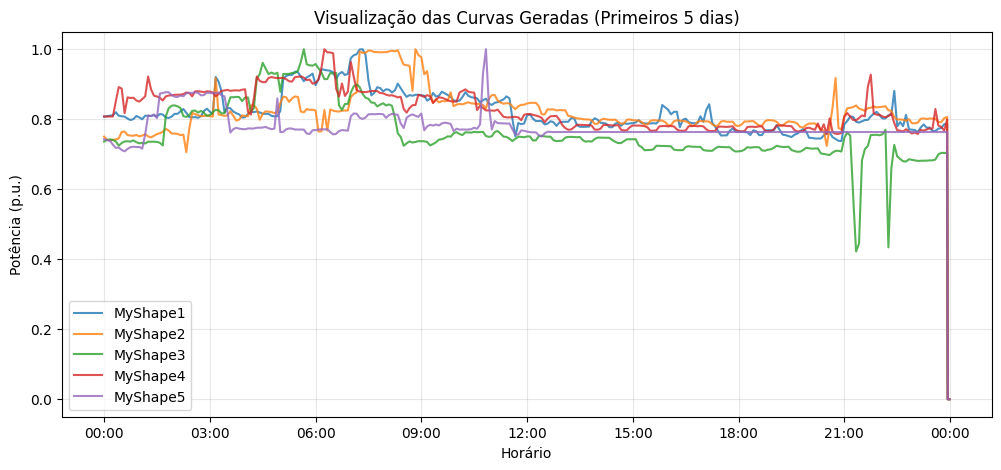

Arquivo DSS gerado com sucesso: D:\UFC\2-MESTRADO\1-semestre\ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)\lucas\trabalho-final\projeto\THP7244-final-project\data\123Bus\LoadShape123Bus_1min.dss


In [94]:
try:
    gerar_dss_baseado_em_arquivo(
        caminho_origem=SOURCE_FILE,
        caminho_saida=OUTPUT_FILE_LOADSHAPE,
        data_inicio_str=DATA_ALVO, # <-- Tente esta data primeiro
        n_dias=QTD_COLUNAS,                     # Quantos dias de curvas você quer
        passo_tempo="1min"              # "1h" ou "15min"
    )
except Exception as e:
    print(f"Erro na execução: {e}")

Gerando arquivos LoadShape PV

---

In [95]:
def gerar_dss_irradiancia(n_colunas, data_alvo, passo_tempo, caminho_origem, caminho_saida):
    """
    Lê um arquivo real e gera N curvas consecutivas.
    AJUSTE FINAL: 
    - Deslocamento fixo de +10 horas.
    - REMOÇÃO TOTAL de qualquer corte de borda (preserva largura original).
    """
    
    print(f"--- Processando Arquivo Real (Offset +10h, Largura Total) ---")
    print(f"Origem: {caminho_origem}")
    print(f"Data Inicial: {data_alvo}")
    
    if not os.path.exists(caminho_origem):
        raise FileNotFoundError(f"Arquivo fonte não encontrado: {caminho_origem}")

    # 1. Ler o Arquivo Fonte
    try:
        df_raw = pd.read_csv(caminho_origem, usecols=['original index', 'solar power (kW)'])
    except ValueError:
        print("Aviso: Colunas padrão não encontradas. Tentando ler por índice...")
        df_raw = pd.read_csv(caminho_origem)
        df_raw = df_raw.iloc[:, [0, 1]]
        df_raw.columns = ['original index', 'solar power (kW)']

    # 2. Processar Tempo
    df_raw['timestamp'] = pd.to_datetime(df_raw['original index'], unit='s')
    df_raw.set_index('timestamp', inplace=True)
    df_raw.sort_index(inplace=True)
    
    curvas = {}
    data_start = pd.Timestamp(data_alvo).normalize()
    
    # Cálculos de Passo de Tempo e Offset
    delta_t = pd.Timedelta(passo_tempo)
    minutos_por_passo = int(delta_t.total_seconds() / 60)
    pontos_por_dia = int(1440 / minutos_por_passo) # 1440 min = 24h
    
    # CÁLCULO DO SHIFT (10 HORAS)
    horas_offset = 10
    pontos_offset = int((horas_offset * 60) / minutos_por_passo)
    
    print(f"Configuração: Passo {passo_tempo}. Pontos/dia: {pontos_por_dia}.")
    print(f"Deslocamento: +{horas_offset}h -> +{pontos_offset} pontos.")

    # --- LOOP PELOS DIAS ---
    for i in range(n_colunas):
        dia_atual = data_start + pd.Timedelta(days=i)
        dia_seguinte = dia_atual + pd.Timedelta(days=1)
        nome_curva = f"MyShapePV{i+1}"
        
        # 3. Filtrar o dia específico
        df_dia = df_raw.loc[(df_raw.index >= dia_atual) & (df_raw.index < dia_seguinte)].copy()
        
        if df_dia.empty:
            curvas[nome_curva] = np.zeros(pontos_por_dia)
            continue

        # 4. Reamostragem
        serie_base = df_dia['solar power (kW)'].resample(passo_tempo).mean()
        serie_base = serie_base.interpolate(method='linear').fillna(0)
        
        # Ajuste de tamanho para garantir exatos 24h
        if len(serie_base) > pontos_por_dia:
            serie_base = serie_base.iloc[:pontos_por_dia]
        elif len(serie_base) < pontos_por_dia:
            serie_base = serie_base.reindex(pd.date_range(dia_atual, periods=pontos_por_dia, freq=passo_tempo), fill_value=0)

        # 5. Tratamento de Sinal (Sem cortes agressivos)
        if serie_base.mean() < 0:
            serie_base = -serie_base
            
        # Opcional: Apenas remove offset base (chão) se houver, sem cortar laterais
        # Se preferir SEM NENHUM tratamento, comente as 3 linhas abaixo
        minimo_dia = serie_base.min()
        if minimo_dia > 0:
             serie_base = serie_base - minimo_dia
        
        serie_base = serie_base.clip(lower=0.0)

        # 6. Normalização (pelo pico do dia)
        pico_dia = serie_base.max()
        if pico_dia == 0: pico_dia = 1.0
        serie_norm = abs(serie_base / pico_dia)
        
        # 7. APLICAÇÃO DO DESLOCAMENTO FIXO (10h)
        # Rola o vetor. O que sai do fim entra no começo (circular).
        # Como não limpamos as bordas, a largura é 100% preservada.
        valores_finais = np.roll(serie_norm.values, shift=pontos_offset)

        curvas[nome_curva] = valores_finais

    # --- PLOTAGEM ---
    plt.figure(figsize=(12, 6))
    eixo_x = pd.date_range(start="2000-01-01", periods=pontos_por_dia, freq=passo_tempo)
    
    for nome, valores in curvas.items():
        # Plotando apenas as primeiras 10 para não poluir, se houver muitas
        if int(nome.replace("MyShapePV", "")) <= 10:
            plt.plot(eixo_x, valores, alpha=0.6, linewidth=1.5, label=nome)
        else:
            plt.plot(eixo_x, valores, alpha=0.3, linewidth=1.0) # Resto mais transparente
        
    plt.title(f"Perfis PV - {n_colunas} Dias (Offset +10h, Largura Original)")
    plt.ylabel("Potência (p.u.)")
    plt.xlabel("Horário (Ajustado)")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.grid(True, alpha=0.3)
    if n_colunas <= 10: plt.legend()
    plt.show()

    # 8. Salvar
    caminho_saida.parent.mkdir(parents=True, exist_ok=True)
    with open(caminho_saida, "w") as f:
        for nome, valores in curvas.items():
            mult_str = ", ".join(f"{v:.4f}" for v in valores)
            f.write(
                f"New LoadShape.{nome} npts={len(valores)} minterval={minutos_por_passo} "
                f"mult=({mult_str})\n"
            )

    print(f"Arquivo DSS gerado: {caminho_saida}")
    return curvas

--- Processando Arquivo Real (Offset +10h, Largura Total) ---
Origem: D:\UFC\2-MESTRADO\1-semestre\ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)\lucas\trabalho-final\projeto\THP7244-final-project\data\nextgen-energy-raw\90-id_261.csv
Data Inicial: 2018-02-04
Configuração: Passo 1min. Pontos/dia: 1440.
Deslocamento: +10h -> +600 pontos.


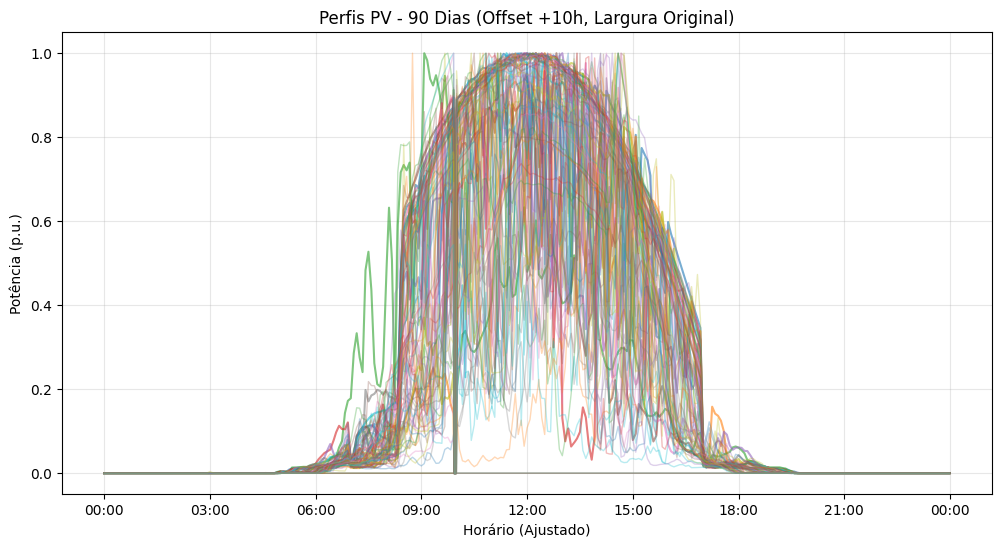

Arquivo DSS gerado: D:\UFC\2-MESTRADO\1-semestre\ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)\lucas\trabalho-final\projeto\THP7244-final-project\data\123Bus\LoadShape123PV_1min.dss


In [96]:
QTD_COLUNAS = 90
DATA_ALVO = '2018-02-04' # Certifique-se que esta data existe no seu CSV!
PASSO_TEMPO = '1min'

SOURCE_FILE = BASE_DIR / "nextgen-energy-raw" / "90-id_261.csv"
OUTPUT_FILE_PV = BASE_DIR / "123Bus" / "LoadShape123PV_1min.dss"

df = gerar_dss_irradiancia(
    n_colunas=QTD_COLUNAS,
    data_alvo=DATA_ALVO,
    passo_tempo=PASSO_TEMPO,
    caminho_origem=SOURCE_FILE,
    caminho_saida=OUTPUT_FILE_PV
)

Gerando arquivos Loads

---

In [97]:
def parse_bus_and_nodes(busname: str):
    """Recebe algo como '671.1.2.3' e retorna ('671', [1,2,3])."""
    parts = busname.split('.')
    barra = parts[0]
    nos = []
    for p in parts[1:]:
        try:
            nos.append(int(p))
        except ValueError:
            continue
    return barra, nos

def distribuir_potencia_por_nos(kW, kvar, nos, is_delta, fases):
    """Distribui potência por nós, convertendo Delta -> Wye equivalente."""
    pot_por_no = {}
    if is_delta:
        if len(nos) >= 3 and fases == 3:
            share_kW = kW / 3.0
            share_kvar = kvar / 3.0
            for no in nos[:3]:
                pot_por_no[no] = {'kW': share_kW, 'kvar': share_kvar}
        elif len(nos) == 2:
            share_kW = kW / 2.0
            share_kvar = kvar / 2.0
            for no in nos:
                pot_por_no[no] = {'kW': share_kW, 'kvar': share_kvar}
        elif len(nos) == 1:
            pot_por_no[nos[0]] = {'kW': kW, 'kvar': kvar}
        else:
            share_kW = kW / float(fases)
            share_kvar = kvar / float(fases)
            for no in range(1, fases + 1):
                pot_por_no[no] = {'kW': share_kW, 'kvar': share_kvar}
    else:
        if len(nos) == 0:
            share_kW = kW / float(max(fases, 1))
            share_kvar = kvar / float(max(fases, 1))
            for no in range(1, max(fases, 1) + 1):
                pot_por_no[no] = {'kW': share_kW, 'kvar': share_kvar}
        elif len(nos) == 1 or fases == 1:
            pot_por_no[nos[0]] = {'kW': kW, 'kvar': kvar}
        else:
            share_kW = kW / float(len(nos))
            share_kvar = kvar / float(len(nos))
            for no in nos:
                pot_por_no[no] = {'kW': share_kW, 'kvar': share_kvar}
    return pot_por_no

def obter_tensoes_base_barra(nome_barra: str):
    """Retorna (kV_LN, kV_LL) da barra."""
    dss.Circuit.SetActiveBus(nome_barra)
    kv_ln = dss.Bus.kVBase()
    kv_ll = dss.Bus.VLL()
    if kv_ln == 0.0 and kv_ll > 0.0:
        kv_ln = kv_ll / math.sqrt(3.0)
    if kv_ll == 0.0 and kv_ln > 0.0:
        kv_ll = kv_ln * math.sqrt(3.0)
    return kv_ln, kv_ll

# -----------------------------
# Função principal: calcular cargas por barra/nó
# -----------------------------
def calcular_cargas_por_barra_e_nos():
    cargas_por_barra = defaultdict(lambda: {
        'total_kW': 0.0,
        'total_kvar': 0.0,
        'nos': defaultdict(lambda: {'kW': 0.0, 'kvar': 0.0}),
        'kV_LN': None,
        # 'kV_LL': None
    })

    dss.Text.Command("CalcVoltageBases")
    dss.Text.Command("Solve")

    dss.Loads.First()
    for _ in range(dss.Loads.Count()):
        busnames = dss.CktElement.BusNames()
        busname = busnames[0] if busnames else dss.Loads.Bus1()

        barra, nos = parse_bus_and_nodes(busname)
        fases = dss.Loads.Phases()
        is_delta = dss.Loads.IsDelta()
        kW = dss.Loads.kW()
        kvar = dss.Loads.kvar()

        pot_por_no = distribuir_potencia_por_nos(kW, kvar, nos, is_delta, fases)

        total_kW_elem = 0.0
        total_kvar_elem = 0.0
        for no, pot in pot_por_no.items():
            cargas_por_barra[barra]['nos'][no]['kW'] += pot['kW']
            cargas_por_barra[barra]['nos'][no]['kvar'] += pot['kvar']
            total_kW_elem += pot['kW']
            total_kvar_elem += pot['kvar']

        cargas_por_barra[barra]['total_kW'] += total_kW_elem
        cargas_por_barra[barra]['total_kvar'] += total_kvar_elem

        kv_ln, kv_ll = obter_tensoes_base_barra(barra)
        cargas_por_barra[barra]['kV_LN'] = kv_ln
        # cargas_por_barra[barra]['kV_LL'] = kv_ll

        dss.Loads.Next()

    return cargas_por_barra

# -----------------------------
# Divisão por carga usando Map_Load_Qtd
# -----------------------------
def calcular_potencia_por_carga(Map_Load_Qtd, cargas_por_barra):
    resultados = {}
    for barra, qtds in Map_Load_Qtd.items():
        info_barra = cargas_por_barra.get(barra, None)
        resultados[barra] = {
            'total_barra': {'kW': 0.0, 'kvar': 0.0},
            'por_no': {
                '1': {'qtd': qtds.get('1', 0), 'kW_total': 0.0, 'kvar_total': 0.0,
                      'kW_por_carga': 0.0, 'kvar_por_carga': 0.0},
                '2': {'qtd': qtds.get('2', 0), 'kW_total': 0.0, 'kvar_total': 0.0,
                      'kW_por_carga': 0.0, 'kvar_por_carga': 0.0},
                '3': {'qtd': qtds.get('3', 0), 'kW_total': 0.0, 'kvar_total': 0.0,
                      'kW_por_carga': 0.0, 'kvar_por_carga': 0.0},
            }
        }

        if info_barra:
            resultados[barra]['total_barra']['kW'] = info_barra['total_kW']
            resultados[barra]['total_barra']['kvar'] = info_barra['total_kvar']
            for no, pot in info_barra['nos'].items():
                no_str = str(no)
                if no_str in resultados[barra]['por_no']:
                    resultados[barra]['por_no'][no_str]['kW_total'] += pot['kW']
                    resultados[barra]['por_no'][no_str]['kvar_total'] += pot['kvar']

            for no in ['1','2','3']:
                qtd = resultados[barra]['por_no'][no]['qtd']
                kW_total = resultados[barra]['por_no'][no]['kW_total']
                kvar_total = resultados[barra]['por_no'][no]['kvar_total']
                if qtd > 0:
                    resultados[barra]['por_no'][no]['kW_por_carga'] = kW_total / qtd
                    resultados[barra]['por_no'][no]['kvar_por_carga'] = kvar_total / qtd
    return resultados

In [98]:
resultado = calcular_potencia_por_carga(Map_Load_Qtd, calcular_cargas_por_barra_e_nos())
cargas_por_barra = calcular_cargas_por_barra_e_nos()

In [99]:
def gerar_comandos_dss(resultados, cargas_por_barra):
    comandos = []
    shape_count = 90   # número de loadshapes disponíveis
    carga_index = 0    # contador global de cargas

    for barra, info in resultados.items():
        for no in ['1','2','3']:
            qtd = info['por_no'][no]['qtd']
            if qtd > 0:
                for i in range(1, qtd+1):
                    carga_index += 1
                    # Seleciona o shape ciclando de 1 até 50
                    shape_id = ((carga_index - 1) % shape_count) + 1
                    shape_name = f"MyShape{shape_id}"

                    kw = info['por_no'][no]['kW_por_carga']
                    kvar = info['por_no'][no]['kvar_por_carga']
                    kv = cargas_por_barra[barra]['kV_LN']

                    cmd = (
                        f"New Load.{barra}_{no}_{i} Bus1={barra}.{no} "
                        f"Phases=1 Conn=Wye Model=1 kV={kv:.3f} "
                        f"kW={kw:.3f} kvar={kvar:.3f} daily={shape_name}"
                    )
                    comandos.append(cmd)
    return comandos


In [100]:
comando = gerar_comandos_dss(resultado, cargas_por_barra)

In [101]:
# Salvar no arquivo Load13Bus.dss
with open(BASE_DIR / "123Bus" / "Load123Bus.dss", "w") as f:
    for cmd in comando:
        f.write(cmd + "\n")

print("Arquivo Load123Bus.dss criado com sucesso!")


Arquivo Load123Bus.dss criado com sucesso!


Gerando arquivos PVs

---

In [102]:
def gerar_pvsystems_de_cargas(caminho_cargas, caminho_saida_pv):
    """
    Lê arquivo DSS de cargas e gera PVSystems correspondentes.
    """
    # Regex para capturar informações das cargas
    regex_load = re.compile(
        r"New Load\.(?P<nome>[^\s]+).*?Bus1=(?P<bus>[^\s]+).*?kV=(?P<kv>[0-9\.]+).*?kW=(?P<kw>[0-9\.]+)",
        re.IGNORECASE
    )

    # Ler arquivo de cargas
    with open(caminho_cargas, "r") as f:
        linhas = f.readlines()

    pv_cmds = []
    shape_count = 90
    pv_index = 0

    for linha in linhas:
        m = regex_load.search(linha)
        if m:
            nome_carga = m.group("nome")
            bus = m.group("bus")
            kv = float(m.group("kv"))
            kw = float(m.group("kw"))

            # Potência PV = 1.2 * kW da carga
            pmpp = kw * 1.5
            kVA = pmpp  # assumindo PF=1

            # Escolher shape sequencial
            pv_index += 1
            shape_id = ((pv_index - 1) % shape_count) + 1
            shape_name = f"MyShapePV{shape_id}"

            # Montar comando PVSystem
            cmd = (
                f"New PVSystem.PV_{nome_carga} phases=1 bus1={bus} kV={kv:.3f} "
                f"kVA={kVA:.3f} irrad=0.8 Pmpp={pmpp:.3f}\n"
                f"~ temperature=25 PF=1 effcurve=Myeff P-TCurve=MyPvsT\n"
                f"~ Daily={shape_name} TDaily=MyTemp\n\n"
            )
            pv_cmds.append(cmd)

    # Salvar em arquivo DSS
    with open(caminho_saida_pv, "w") as f:
        f.writelines(pv_cmds)

    print(f"Arquivo DSS de PVSystems gerado: {caminho_saida_pv}")
    return pv_cmds


In [103]:
PV = gerar_pvsystems_de_cargas(BASE_DIR / "123Bus" / "Load123Bus.dss",
                               BASE_DIR / "123Bus" / "PVSystem123Bus.dss")

Arquivo DSS de PVSystems gerado: D:\UFC\2-MESTRADO\1-semestre\ESTUDOS ESPECIAIS EM ENGENHARIA ELETRICA II (THP7244)\lucas\trabalho-final\projeto\THP7244-final-project\data\123Bus\PVSystem123Bus.dss
